## **Every Session: Mount Drive**

Run this cell first in every Colab session. It mounts Drive and checks that the neesed data files  are there.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

# Shared paths used by all analysis sections
RAW_PATH  = "/content/drive/MyDrive/eyebench_data/OneStop/precomputed_reading_measures/ia_Paragraph.csv"
TRIAL_OUT = "/content/drive/MyDrive/eyebench_data/trial_level.csv"
WORD_OUT  = "/content/drive/MyDrive/eyebench_data/word_level_slim.csv"

import os
print("Drive mounted.")
print("Raw file present:", os.path.exists(RAW_PATH))
print("Trial table present:", os.path.exists(TRIAL_OUT))
print("Word table present:", os.path.exists(WORD_OUT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Raw file present: True
Trial table present: True
Word table present: True


## **Run Once: Download the Data**

Downloads the OneStop word-level file (the same file EyeBench uses) to Drive. Only needed the first time, and it needs about 6 GB of free space.

In [9]:
import os
import hashlib
import subprocess

# Same folder the "Every Session" cell expects
DATA_DIR = "/content/drive/MyDrive/eyebench_data/OneStop/precomputed_reading_measures"
RAW_PATH = DATA_DIR + "/ia_Paragraph.csv"

# This is the file EyeBench downloads for OneStop (through pymovements).
# Only the word-level reading measures file is needed
URL = "https://osf.io/download/4ajc8/"
ZIP_PATH = "/content/ia_Paragraph.csv.zip"
EXPECTED_MD5 = "9b9548e49efdc7dbf63d4f3a5dc3af22"

if not os.path.isdir("/content/drive/MyDrive"):
    raise RuntimeError("Drive is not mounted, run the Every Session cell first.")

if os.path.exists(RAW_PATH):
    print("Raw file already on Drive, nothing to download.")
else:
    os.makedirs(DATA_DIR, exist_ok=True)

    print("Downloading (about 380 MB)...")
    subprocess.run(["wget", "-q", "-O", ZIP_PATH, URL], check=True)

    # Make sure the download is complete before unzipping
    md5 = hashlib.md5()
    with open(ZIP_PATH, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            md5.update(block)
    if md5.hexdigest() != EXPECTED_MD5:
        raise ValueError("Download looks broken (checksum mismatch), run the cell again.")

    print("Unzipping to Drive (a few minutes)...")
    subprocess.run(["unzip", "-o", "-q", ZIP_PATH, "-d", DATA_DIR], check=True)
    os.remove(ZIP_PATH)

print(f"Raw file size: {os.path.getsize(RAW_PATH) / (1024 * 1024):.0f}" )


Raw file already on Drive, nothing to download.
Raw file size: 5358


# **Stage 1: Data Preparation and Pupil Characterization**

We start by understanding and reducing the raw OneStop file. Then we look at how pupil behaves during reading and whether the whole-passage pupil says anything about comprehension.

## **Section 1: Data Structure Inspection**

Before aggregating anything, we look at how the raw file is organized: participants, articles, paragraphs, words, questions and the correct/incorrect label.

In [10]:
import pandas as pd

# Path to the file saved on Drive
path = "/content/drive/MyDrive/eyebench_data/OneStop/precomputed_reading_measures/ia_Paragraph.csv"

# The file is large, so we read it in chunks and keep only the first participant we encounter.
# This avoids loading all 5.3 GB into memory just to look at the structure.
first_participant = None
collected = []

for chunk in pd.read_csv(path, chunksize=100000, low_memory=False):
    if first_participant is None:
        first_participant = chunk["participant_id"].iloc[0]
    # Keep only rows belonging to the first participant
    part_rows = chunk[chunk["participant_id"] == first_participant]
    collected.append(part_rows)
    # Once we stop seeing the first participant, we have all their rows
    if first_participant not in chunk["participant_id"].values:
        break

one_participant = pd.concat(collected, ignore_index=True)

print("Selected participant:", first_participant)
print("Number of rows for this participant:", len(one_participant))
print()

# Look at how the reading is organized for this participant.
# We want to understand the hierarchy: articles, paragraphs, words.
print("Number of unique articles:", one_participant["article_id"].nunique())
print("Number of unique paragraphs (article + paragraph):",
      one_participant.groupby(["article_id", "paragraph_id"]).ngroups)
print()

# Look at one single trial (one article, one paragraph) to see the word-level layout.
one_trial = one_participant[
    (one_participant["article_id"] == one_participant["article_id"].iloc[0]) &
    (one_participant["paragraph_id"] == one_participant["paragraph_id"].iloc[0])
]

print("Columns that describe the trial structure and label:")
cols_to_show = ["article_id", "paragraph_id", "IA_ID", "IA_LABEL",
                "question", "is_correct"]
print(one_trial[cols_to_show].head(15).to_string())
print()

# Check whether is_correct is the same value across all words in a trial.
# If it is, that confirms the label belongs to the trial, not to individual words.
print("Unique is_correct values within this single trial:",
      one_trial["is_correct"].unique())

Selected participant: l42_2070
Number of rows for this participant: 7736

Number of unique articles: 11
Number of unique paragraphs (article + paragraph): 56

Columns that describe the trial structure and label:
    article_id  paragraph_id  IA_ID    IA_LABEL                                                                                                                  question  is_correct
0            0             1      1     Leading  According to Malik Falkenmark's report, what will happen if the world adopts the current diet trends of western nations?        True
1            0             1      2       water  According to Malik Falkenmark's report, what will happen if the world adopts the current diet trends of western nations?        True
2            0             1      3  scientists  According to Malik Falkenmark's report, what will happen if the world adopts the current diet trends of western nations?        True
3            0             1      4        have  According t

In [11]:
# Look at one article for this participant and see the label per paragraph.
# This tells us whether every paragraph has its own question and outcome,
# or whether only one paragraph per article is tested.

# Pick the first article for this participant
example_article = one_participant["article_id"].iloc[0]
article_rows = one_participant[one_participant["article_id"] == example_article]

# For each paragraph in this article, show the question and the label.
# We take the first row of each paragraph since the values are constant within a trial.
summary = (
    article_rows
    .groupby("paragraph_id")
    .agg(
        question=("question", "first"),
        is_correct=("is_correct", "first"),
        n_words=("IA_ID", "count"),
    )
    .reset_index()
)

print("Article:", example_article)
print("Number of paragraphs in this article:", len(summary))
print()

# Show the label and word count per paragraph.
# We shorten the question text so it fits on screen.
summary["question_short"] = summary["question"].str.slice(0, 50)
print(summary[["paragraph_id", "is_correct", "n_words", "question_short"]].to_string())

Article: 0
Number of paragraphs in this article: 2

   paragraph_id  is_correct  n_words                                      question_short
0             1        True      128  According to Malik Falkenmark's report, what will 
1             2        True      148  Which factor led to the increase in the price of c


## **Section 2: Preprocessing**

We read the large raw file once and save two smaller tables, one row per trial and one row per word, leaving out the two practice trials each participant read first. A paragraph can come with more than one question and the raw file repeats its words for each one, so a trial is a single question instance (participant, article, paragraph and question id).

In [12]:
import pandas as pd
import numpy as np

# Paths
RAW_PATH = "/content/drive/MyDrive/eyebench_data/OneStop/precomputed_reading_measures/ia_Paragraph.csv"
TRIAL_OUT = "/content/drive/MyDrive/eyebench_data/trial_level.csv"
WORD_OUT = "/content/drive/MyDrive/eyebench_data/word_level_slim.csv"

# A paragraph can be paired with more than one comprehension question, and the raw
# file repeats the word rows once per question. So the correct unit is one question
# instance: participant, article, paragraph, and question id together. We key
# everything on that, so each question instance is its own trial with its own words
# and its own correct/incorrect label, and no word gets double-counted.
TRIAL_KEYS = ["participant_id", "article_id", "paragraph_id", "onestopqa_question_id"]

# Columns we read from the raw file. Loading only these keeps memory reasonable.
USECOLS = TRIAL_KEYS + [
    "IA_ID", "IA_LABEL",
    "IA_AVERAGE_FIX_PUPIL_SIZE", "IA_MAX_FIX_PUPIL_SIZE",
    "IA_FIRST_FIXATION_DURATION", "IA_DWELL_TIME",
    "IA_SKIP", "IA_REGRESSION_IN", "IA_REGRESSION_OUT",
    "gpt2_surprisal", "wordfreq_frequency",
    "difficulty_level", "is_correct",
    "critical_span_indices", "distractor_span_indices",
    "practice_trial",
]

# These columns are stored as text with "." for missing. We turn them into numbers,
# so missing becomes NaN.
NUMERIC_COLS = [
    "IA_AVERAGE_FIX_PUPIL_SIZE", "IA_MAX_FIX_PUPIL_SIZE",
    "IA_FIRST_FIXATION_DURATION", "IA_DWELL_TIME",
    "IA_SKIP", "IA_REGRESSION_IN", "IA_REGRESSION_OUT",
    "gpt2_surprisal", "wordfreq_frequency",
]

# The slim word table keeps all words and the word order (IA_ID), now also keyed by
# question id, so the windowing and the critical-span work stay inside one question
# instance.
WORD_COLS = TRIAL_KEYS + ["IA_ID", "IA_AVERAGE_FIX_PUPIL_SIZE",
                          "gpt2_surprisal", "wordfreq_frequency",
                          "IA_SKIP", "difficulty_level",
                          "critical_span_indices", "distractor_span_indices"]

word_slim_chunks = []
trial_pieces = []

print("Reading raw file in chunks...")
rows_seen = 0
for chunk in pd.read_csv(RAW_PATH, usecols=USECOLS, chunksize=200000, low_memory=False):
    for col in NUMERIC_COLS:
        chunk[col] = pd.to_numeric(chunk[col], errors="coerce")

    # Drop the practice article. Each participant first read a short practice
    # article (two trials) before the real ones, so these are not part of the experiment.
    chunk = chunk[chunk["practice_trial"] == False]

    # Save the slim word-level rows (all words, selected columns).
    word_slim_chunks.append(chunk[WORD_COLS].copy())

    # Per-chunk partial trial aggregation. A trial can be split across two chunks,
    # so we aggregate per chunk and combine the partials afterwards.
    piece = chunk.groupby(TRIAL_KEYS).agg(
        pupil_sum=("IA_AVERAGE_FIX_PUPIL_SIZE", "sum"),
        pupil_sqsum=("IA_AVERAGE_FIX_PUPIL_SIZE", lambda x: np.nansum(x**2)),
        pupil_n=("IA_AVERAGE_FIX_PUPIL_SIZE", "count"),
        pupil_max=("IA_MAX_FIX_PUPIL_SIZE", "max"),
        fixdur_sum=("IA_FIRST_FIXATION_DURATION", "sum"),
        fixdur_n=("IA_FIRST_FIXATION_DURATION", "count"),
        dwell_sum=("IA_DWELL_TIME", "sum"),
        surprisal_sum=("gpt2_surprisal", "sum"),
        surprisal_n=("gpt2_surprisal", "count"),
        frequency_sum=("wordfreq_frequency", "sum"),
        frequency_n=("wordfreq_frequency", "count"),
        skip_sum=("IA_SKIP", "sum"),
        regin_sum=("IA_REGRESSION_IN", "sum"),
        regout_sum=("IA_REGRESSION_OUT", "sum"),
        word_count=("IA_LABEL", "count"),
        difficulty=("difficulty_level", "first"),
        is_correct=("is_correct", "first"),
    )
    trial_pieces.append(piece)

    rows_seen += len(chunk)
    print("  rows processed:", rows_seen)

# Combine the partial trial aggregates. We sum the partials that belong to the same
# trial, then turn sums and counts into the final means.
print("Combining trial aggregates...")
combined = pd.concat(trial_pieces)
grouped = combined.groupby(level=[0, 1, 2, 3])

trial = pd.DataFrame()
trial["mean_pupil"] = grouped["pupil_sum"].sum() / grouped["pupil_n"].sum()
pupil_n = grouped["pupil_n"].sum()
pupil_mean = grouped["pupil_sum"].sum() / pupil_n
pupil_var = grouped["pupil_sqsum"].sum() / pupil_n - pupil_mean**2
trial["std_pupil"] = np.sqrt(pupil_var.clip(lower=0))
trial["max_pupil"] = grouped["pupil_max"].max()
trial["mean_fix_dur"] = grouped["fixdur_sum"].sum() / grouped["fixdur_n"].sum()
trial["total_dwell"] = grouped["dwell_sum"].sum()
trial["mean_surprisal"] = grouped["surprisal_sum"].sum() / grouped["surprisal_n"].sum()
trial["mean_frequency"] = grouped["frequency_sum"].sum() / grouped["frequency_n"].sum()
trial["n_words"] = grouped["word_count"].sum()
trial["skip_rate"] = grouped["skip_sum"].sum() / trial["n_words"]
trial["regression_in_rate"] = grouped["regin_sum"].sum() / trial["n_words"]
trial["regression_out_rate"] = grouped["regout_sum"].sum() / trial["n_words"]
trial["difficulty"] = grouped["difficulty"].first()
trial["is_correct"] = grouped["is_correct"].first()
trial = trial.reset_index()

print("Combining slim word-level table...")
word_slim = pd.concat(word_slim_chunks, ignore_index=True)

trial.to_csv(TRIAL_OUT, index=False)
word_slim.to_csv(WORD_OUT, index=False)

print("Done.")
print("Trial-level table shape:", trial.shape)
print("Word-level slim table shape:", word_slim.shape)


Reading raw file in chunks...
  rows processed: 192548
  rows processed: 385096
  rows processed: 577368
  rows processed: 769640
  rows processed: 962464
  rows processed: 1154736
  rows processed: 1347008
  rows processed: 1539832
  rows processed: 1732104
  rows processed: 1924376
  rows processed: 2116924
  rows processed: 2309196
  rows processed: 2501744
  rows processed: 2532799
Combining trial aggregates...
Combining slim word-level table...
Done.
Trial-level table shape: (23326, 17)
Word-level slim table shape: (2532799, 12)


## **Section 2b: Checking the Trial Table**

A quick look at the saved trial table: its size, the label split, and missing values in the main columns.

In [13]:
import pandas as pd

TRIAL_OUT = "/content/drive/MyDrive/eyebench_data/trial_level.csv"
trial = pd.read_csv(TRIAL_OUT)

# The trial table is now keyed by question instance, so there are more trials than
# the old paragraph-level version (paragraphs with two questions become two trials).
# Here we just sanity check the rebuilt table: shape, label split, difficulty split,
# no missing values, and reasonable ranges.
print("Shape:", trial.shape)
print()

print("Comprehension label split:")
print(trial["is_correct"].value_counts(normalize=True).round(3))
print()

print("Difficulty split:")
print(trial["difficulty"].value_counts())
print()

print("Missing values in key columns (expected all zero):")
print(trial[["mean_pupil", "mean_fix_dur", "mean_surprisal",
             "mean_frequency", "skip_rate", "n_words", "is_correct"]].isna().sum())
print()

print("Quick ranges:")
print(trial[["mean_pupil", "mean_fix_dur", "skip_rate", "n_words"]].describe().round(2))


Shape: (23326, 17)

Comprehension label split:
is_correct
True     0.846
False    0.154
Name: proportion, dtype: float64

Difficulty split:
difficulty
Adv    11663
Ele    11663
Name: count, dtype: int64

Missing values in key columns (expected all zero):
mean_pupil        0
mean_fix_dur      0
mean_surprisal    0
mean_frequency    0
skip_rate         0
n_words           0
is_correct        0
dtype: int64

Quick ranges:
       mean_pupil  mean_fix_dur  skip_rate   n_words
count    23326.00      23326.00   23326.00  23326.00
mean       873.91        188.51       0.60    108.58
std        244.60         28.22       0.15     28.16
min        348.60        102.84       0.12     50.00
25%        691.96        169.00       0.50     85.00
50%        860.49        186.31       0.59    107.00
75%       1020.33        205.08       0.70    131.00
max       1964.82        521.17       0.99    165.00


## **Section 3: Does Pupil Track Word Difficulty?**

We check whether pupil is larger on harder words, using surprisal and word frequency averaged over a five-word window. Pupil is centered within each reader, and both measures go into one regression.

In [14]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

WORD_OUT = "/content/drive/MyDrive/eyebench_data/word_level_slim.csv"
word = pd.read_csv(WORD_OUT)

TRIAL_KEYS = ["participant_id", "article_id", "paragraph_id", "onestopqa_question_id"]

# Sort so that words are in reading order within each trial.
# This is required before we take a rolling window over neighbors.
word = word.sort_values(TRIAL_KEYS + ["IA_ID"]).reset_index(drop=True)

# We build a 5-word window for each center word: 2 before, the center, 2 after.
# The window must stay inside the same trial, so we compute it per trial group.
WINDOW = 5  # 2 before + center + 2 after

def window_mean(s):
    # Rolling mean centered on each word. min_periods=1 means edge words still get
    # a value from whatever neighbors exist inside the trial. NaN values are skipped,
    # so for pupil this is the mean over the fixated words in the window only, and
    # it is NaN only if the whole window was skipped.
    return s.rolling(WINDOW, center=True, min_periods=1).mean()

print("Building windowed features per trial...")
by_trial = word.groupby(TRIAL_KEYS)
word["surprisal_win"] = by_trial["gpt2_surprisal"].transform(window_mean)
word["frequency_win"] = by_trial["wordfreq_frequency"].transform(window_mean)
word["pupil_win"] = by_trial["IA_AVERAGE_FIX_PUPIL_SIZE"].transform(window_mean)

# Keep only rows where the window has a pupil value (at least one fixated word nearby)
word_win = word.dropna(subset=["pupil_win", "surprisal_win", "frequency_win"]).copy()
print("Rows with a valid window:", len(word_win))

# Per-reader centering of the windowed pupil: each window's pupil relative to
# that reader's own average windowed pupil.
word_win["pupil_centered"] = (
    word_win["pupil_win"]
    - word_win.groupby("participant_id")["pupil_win"].transform("mean")
)

# Joint regression: surprisal and frequency together, so each is controlled for the other.
model = smf.ols("pupil_centered ~ surprisal_win + frequency_win", data=word_win).fit()
print(model.summary())


Building windowed features per trial...
Rows with a valid window: 2405230
                            OLS Regression Results                            
Dep. Variable:         pupil_centered   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     3256.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:25:10   Log-Likelihood:            -1.4034e+07
No. Observations:             2405230   AIC:                         2.807e+07
Df Residuals:                 2405227   BIC:                         2.807e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

## **Section 3b: Word-Difficulty Effect Per Participant**

The same regression, run separately for each reader, to see whether the effect shows up in most readers and not only in the pooled data.

Participants included: 360
Surprisal coefficient positive: 277 of 360 participants
Frequency coefficient negative: 265 of 360 participants
Mean surprisal coefficient: 3.068
Mean frequency coefficient: -1.326


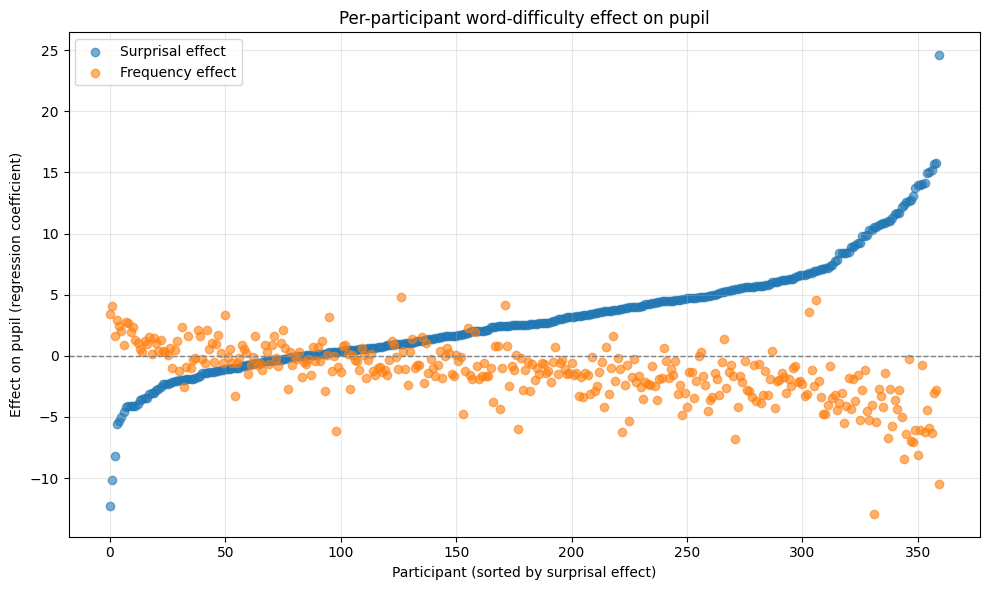

In [15]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Run the same windowed regression separately for each participant, reusing
# word_win from the previous cell. We store each participant's surprisal and
# frequency coefficients.
results = []
for pid, group in word_win.groupby("participant_id"):
    # Need enough words to fit a stable regression.
    if len(group) < 50:
        continue
    m = smf.ols("pupil_centered ~ surprisal_win + frequency_win", data=group).fit()
    results.append({
        "participant_id": pid,
        "surprisal_coef": m.params["surprisal_win"],
        "frequency_coef": m.params["frequency_win"],
    })

coefs = pd.DataFrame(results)

# How many participants show the effect in the expected direction.
# Expected: surprisal positive (more surprising -> bigger pupil),
# frequency negative (rarer words -> bigger pupil).
n_surprisal_pos = (coefs["surprisal_coef"] > 0).sum()
n_frequency_neg = (coefs["frequency_coef"] < 0).sum()
print("Participants included:", len(coefs))
print(f"Surprisal coefficient positive: {n_surprisal_pos} of {len(coefs)} participants")
print(f"Frequency coefficient negative: {n_frequency_neg} of {len(coefs)} participants")
print("Mean surprisal coefficient:", round(coefs["surprisal_coef"].mean(), 3))
print("Mean frequency coefficient:", round(coefs["frequency_coef"].mean(), 3))

# Sort participants by their surprisal coefficient, lowest on the left.
# Both series are plotted at the same x positions, so each x is the same participant.
coefs_sorted = coefs.sort_values("surprisal_coef").reset_index(drop=True)
x = range(len(coefs_sorted))

plt.figure(figsize=(10, 6))
plt.scatter(x, coefs_sorted["surprisal_coef"], alpha=0.6,
            label="Surprisal effect", color="tab:blue")
plt.scatter(x, coefs_sorted["frequency_coef"], alpha=0.6,
            label="Frequency effect", color="tab:orange")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Participant (sorted by surprisal effect)")
plt.ylabel("Effect on pupil (regression coefficient)")
plt.title("Per-participant word-difficulty effect on pupil")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("per_participant_word_effect_sorted.png", dpi=150)
plt.show()

## **Section 4: Pupil Across the Passage**

We look at how pupil changes from the start to the end of a passage. The position curve we get here is used later to remove this drift.

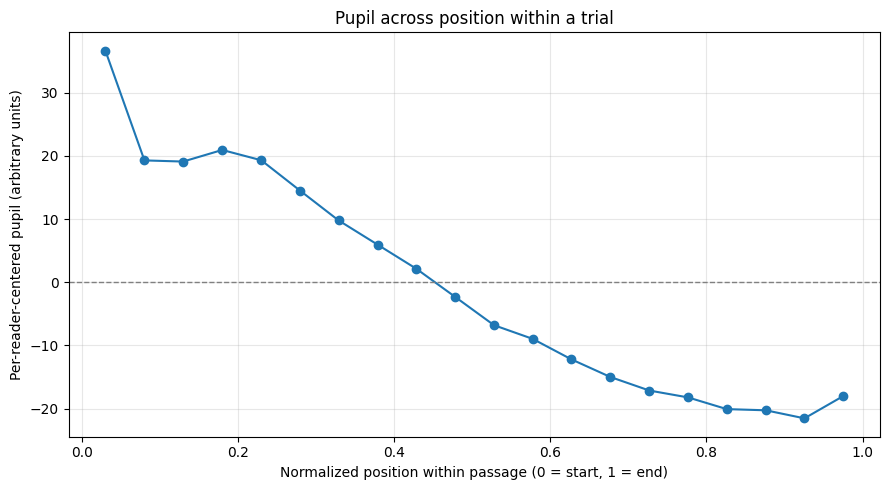

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

WORD_OUT = "/content/drive/MyDrive/eyebench_data/word_level_slim.csv"
word = pd.read_csv(WORD_OUT)
TRIAL_KEYS = ["participant_id", "article_id", "paragraph_id", "onestopqa_question_id"]

# Keep only fixated words, since only they have a pupil value.
word = word.dropna(subset=["IA_AVERAGE_FIX_PUPIL_SIZE"]).copy()

# Center pupil within each reader, so each value is relative to that reader's baseline.
word["pupil_centered"] = (
    word["IA_AVERAGE_FIX_PUPIL_SIZE"]
    - word.groupby("participant_id")["IA_AVERAGE_FIX_PUPIL_SIZE"].transform("mean")
)

# Compute each word's normalized position within its trial (0 = start, 1 = end).
word["max_ia"] = word.groupby(TRIAL_KEYS)["IA_ID"].transform("max")
word["norm_position"] = word["IA_ID"] / word["max_ia"]

# Average centered pupil within 20 position bins. This is the position curve,
# which we both plot here and reuse later to detrend the comprehension comparison.
word["position_bin"] = pd.cut(word["norm_position"], bins=20)
position_curve = word.groupby("position_bin", observed=True)["pupil_centered"].mean()

# Bin midpoints for plotting.
profile = position_curve.reset_index()
profile["bin_mid"] = profile["position_bin"].apply(lambda b: b.mid)

plt.figure(figsize=(9, 5))
plt.plot(profile["bin_mid"], profile["pupil_centered"], marker="o")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Normalized position within passage (0 = start, 1 = end)")
plt.ylabel("Per-reader-centered pupil (arbitrary units)")
plt.title("Pupil across position within a trial")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pupil_position_profile.png", dpi=150)
plt.show()

## **Section 4b: Difficulty Levels**

We compare Advanced and Elementary trials on length, reading time and word properties, to see whether the difficulty levels differ in ways that could affect pupil.

In [17]:
import pandas as pd
from scipy import stats

TRIAL_OUT = "/content/drive/MyDrive/eyebench_data/trial_level.csv"
trial = pd.read_csv(TRIAL_OUT)

# Compare basic trial properties between the two difficulty levels.
# We look at the features that could differ and affect pupil or comprehension.
features_to_check = ["n_words", "total_dwell", "skip_rate",
                     "mean_fix_dur", "mean_surprisal", "mean_frequency"]

print("Comparison of trial properties by difficulty level:")
print()
print(trial.groupby("difficulty")[features_to_check].mean().round(2).T)
print()

# Run a t-test on each feature to see which differences are systematic.
print("t-tests for each feature (Advanced vs Elementary):")
for feat in features_to_check:
    adv = trial[trial["difficulty"] == "Adv"][feat]
    ele = trial[trial["difficulty"] == "Ele"][feat]
    t_stat, p_val = stats.ttest_ind(adv, ele, equal_var=False)
    print(f"  {feat:18s}  Adv={adv.mean():8.2f}  Ele={ele.mean():8.2f}  "
          f"t={t_stat:7.2f}  p={p_val:.2e}")

# Also check comprehension accuracy by difficulty, since that is directly relevant.
print()
print("Comprehension accuracy by difficulty level:")
print(trial.groupby("difficulty")["is_correct"].mean().round(3))

Comparison of trial properties by difficulty level:

difficulty           Adv       Ele
n_words           120.00     97.17
total_dwell     20724.65  16102.80
skip_rate           0.60      0.60
mean_fix_dur      189.58    187.45
mean_surprisal      4.26      4.06
mean_frequency     11.28     10.99

t-tests for each feature (Advanced vs Elementary):
  n_words             Adv=  120.00  Ele=   97.17  t=  67.73  p=0.00e+00
  total_dwell         Adv=20724.65  Ele=16102.80  t=  34.24  p=2.46e-250
  skip_rate           Adv=    0.60  Ele=    0.60  t=  -0.55  p=5.82e-01
  mean_fix_dur        Adv=  189.58  Ele=  187.45  t=   5.78  p=7.63e-09
  mean_surprisal      Adv=    4.26  Ele=    4.06  t=  29.30  p=2.48e-185
  mean_frequency      Adv=   11.28  Ele=   10.99  t=  31.12  p=2.20e-208

Comprehension accuracy by difficulty level:
difficulty
Adv    0.837
Ele    0.855
Name: is_correct, dtype: float64


## **Section 4c: Passage Length and Comprehension**

We compare correct and incorrect trials on length and reading time, to check that a pupil difference between them would not just come from passage length.

In [18]:
import pandas as pd
from scipy import stats

TRIAL_OUT = "/content/drive/MyDrive/eyebench_data/trial_level.csv"
trial = pd.read_csv(TRIAL_OUT)

# Compare trial properties between correct and incorrect trials,
# focusing on the length-related features that drove the difficulty confound.
features_to_check = ["n_words", "total_dwell", "skip_rate",
                     "mean_fix_dur", "mean_surprisal", "mean_frequency"]

print("Comparison of trial properties by comprehension outcome:")
print()
print(trial.groupby("is_correct")[features_to_check].mean().round(2).T)
print()

print("t-tests for each feature (correct vs incorrect):")
for feat in features_to_check:
    correct = trial[trial["is_correct"] == True][feat]
    incorrect = trial[trial["is_correct"] == False][feat]
    t_stat, p_val = stats.ttest_ind(correct, incorrect, equal_var=False)
    print(f"  {feat:18s}  Correct={correct.mean():8.2f}  "
          f"Incorrect={incorrect.mean():8.2f}  t={t_stat:7.2f}  p={p_val:.2e}")

Comparison of trial properties by comprehension outcome:

is_correct         False     True 
n_words           109.99    108.33
total_dwell     19490.10  18217.93
skip_rate           0.58      0.60
mean_fix_dur      190.73    188.11
mean_surprisal      4.18      4.16
mean_frequency     11.24     11.11

t-tests for each feature (correct vs incorrect):
  n_words             Correct=  108.33  Incorrect=  109.99  t=  -3.27  p=1.09e-03
  total_dwell         Correct=18217.93  Incorrect=19490.10  t=  -6.49  p=9.35e-11
  skip_rate           Correct=    0.60  Incorrect=    0.58  t=   7.18  p=7.96e-13
  mean_fix_dur        Correct=  188.11  Incorrect=  190.73  t=  -4.90  p=9.84e-07
  mean_surprisal      Correct=    4.16  Incorrect=    4.18  t=  -2.45  p=1.43e-02
  mean_frequency      Correct=   11.11  Incorrect=   11.24  t= -10.00  p=2.55e-23


## **Section 5: Whole-Passage Pupil and Comprehension**

After removing the position drift, we compare the average pupil of correct and incorrect trials.

In [19]:
from scipy import stats

TRIAL_OUT = "/content/drive/MyDrive/eyebench_data/trial_level.csv"
trial = pd.read_csv(TRIAL_OUT)

# Reuse the word frame and position_curve from Section 4.
# Subtract the expected pupil at each word's position to remove the position drift.
word["position_expected"] = word["position_bin"].map(position_curve).astype(float)
word["pupil_detrended"] = word["pupil_centered"] - word["position_expected"]

# Average the detrended residual per trial, then attach the comprehension label.
detrended = word.groupby(TRIAL_KEYS)["pupil_detrended"].mean().reset_index()
detrended = detrended.merge(trial[TRIAL_KEYS + ["is_correct"]], on=TRIAL_KEYS)

correct = detrended[detrended["is_correct"] == True]["pupil_detrended"]
incorrect = detrended[detrended["is_correct"] == False]["pupil_detrended"]

print("Position-detrended pupil by comprehension outcome:")
print("  correct trials:   mean =", round(correct.mean(), 3), " n =", len(correct))
print("  incorrect trials: mean =", round(incorrect.mean(), 3), " n =", len(incorrect))
print()

t_stat, p_val = stats.ttest_ind(correct, incorrect, equal_var=False)
print("t-test (correct vs incorrect):")
print("  t =", round(t_stat, 3))
print("  p =", p_val)

pooled_std = np.sqrt((correct.var() + incorrect.var()) / 2)
cohens_d = (correct.mean() - incorrect.mean()) / pooled_std
print("  Cohen's d =", round(cohens_d, 4))

detrended_with_part = detrended.copy()

Position-detrended pupil by comprehension outcome:
  correct trials:   mean = 2.807  n = 19736
  incorrect trials: mean = 2.7  n = 3590

t-test (correct vs incorrect):
  t = 0.105
  p = 0.9167354203343133
  Cohen's d = 0.0019


## **Section 5b: Whole-Passage Effect Per Participant**

The correct-minus-incorrect pupil difference for each reader, sorted from lowest to highest.

Participants with both correct and incorrect trials: 356
Higher pupil on incorrect trials: 185 of 356
Mean per-participant difference (incorrect - correct): 0.173


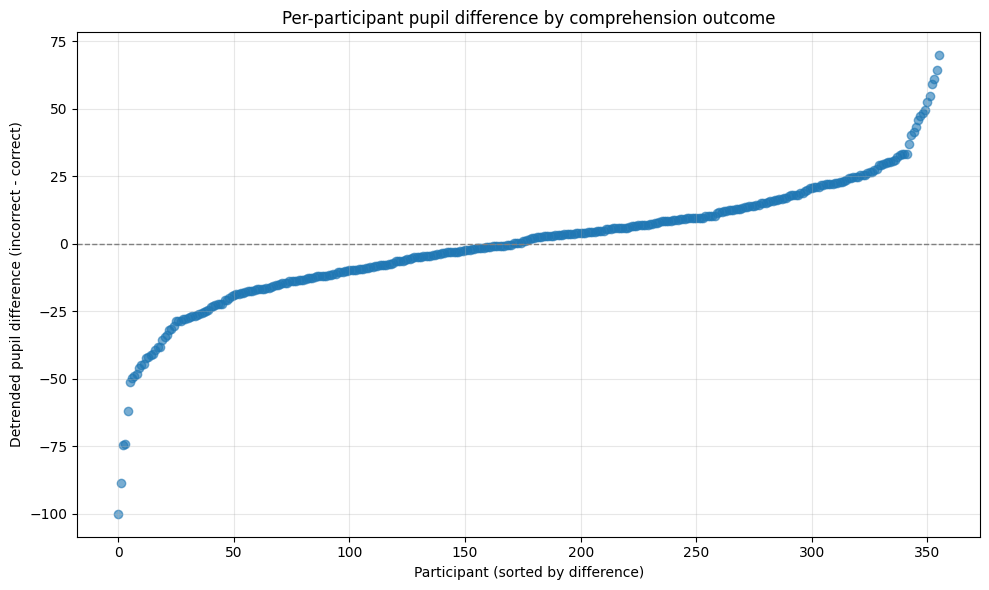

In [20]:
import matplotlib.pyplot as plt

# For each participant, compute mean detrended pupil on correct and on incorrect trials.
per_part = (
    detrended_with_part
    .groupby(["participant_id", "is_correct"])["pupil_detrended"]
    .mean()
    .unstack("is_correct")
)
per_part.columns = ["incorrect_mean", "correct_mean"]

# Difference is incorrect minus correct. A positive value means higher pupil when wrong.
per_part["difference"] = per_part["incorrect_mean"] - per_part["correct_mean"]

# A difference needs both groups, so participants with no incorrect trials give NaN
# and are dropped. This is not a quality filter, the difference just cannot be computed.
per_part = per_part.dropna(subset=["difference"])

n_higher_when_wrong = (per_part["difference"] > 0).sum()
print("Participants with both correct and incorrect trials:", len(per_part))
print(f"Higher pupil on incorrect trials: {n_higher_when_wrong} of {len(per_part)}")
print("Mean per-participant difference (incorrect - correct):",
      round(per_part["difference"].mean(), 3))

# Scatter with participants sorted by their difference, lowest on the left.
per_part_sorted = per_part.sort_values("difference").reset_index()
x = range(len(per_part_sorted))

plt.figure(figsize=(10, 6))
plt.scatter(x, per_part_sorted["difference"], alpha=0.6)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Participant (sorted by difference)")
plt.ylabel("Detrended pupil difference (incorrect - correct)")
plt.title("Per-participant pupil difference by comprehension outcome")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("per_participant_outcome_diff.png", dpi=150)
plt.show()

# **Stage 2: Critical Span Analysis**

The whole-passage pupil told us very little about comprehension, so here we focus on specific parts of the text: the critical span, which holds the answer, and the distractor span, which supports a wrong answer.

## **Section 1: Mapping the Spans to Words**

The spans are stored as 0-based, half-open ranges of word positions, so the word with IA_ID i is inside (start, end) when start <= i - 1 < end. We print a few examples to make sure this gives clean phrases.

In [21]:
import pandas as pd
import ast

RAW_PATH = "/content/drive/MyDrive/eyebench_data/OneStop/precomputed_reading_measures/ia_Paragraph.csv"

# The critical span and distractor span are stored as ranges of word positions,
# for example [(80, 128)]. These positions are 0-based and half-open, meaning a
# range (start, end) covers the words from start up to but not including end.
# Since IA_ID starts at 1, the word with IA_ID i falls in the range when
# start <= (i - 1) < end. This cell confirms that rule produces clean, sensible
# phrases by printing the critical and distractor text for a few example trials.

# Read one slice of the raw file, enough to contain several trials.
sample = next(pd.read_csv(RAW_PATH, chunksize=60000, low_memory=False))
# A trial is one question instance, so the question id is part of the key.
# Without it, paragraphs with two questions would show every word twice.
keys = ["participant_id", "article_id", "paragraph_id", "onestopqa_question_id"]
trial_ids = sample[keys].drop_duplicates().head(5).values

# Return the words whose position falls inside a span, using the half-open rule.
def words_in_span(one_trial, start, end):
    mask = ((one_trial["IA_ID"] - 1) >= start) & ((one_trial["IA_ID"] - 1) < end)
    return " ".join(one_trial.loc[mask, "IA_LABEL"].astype(str))

for pid, aid, parid, qid in trial_ids:
    one_trial = sample[
        (sample["participant_id"] == pid) &
        (sample["article_id"] == aid) &
        (sample["paragraph_id"] == parid) &
        (sample["onestopqa_question_id"] == qid)
    ].sort_values("IA_ID")

    crit = ast.literal_eval(one_trial["critical_span_indices"].iloc[0])
    dist = ast.literal_eval(one_trial["distractor_span_indices"].iloc[0])

    print("=" * 70)
    print(f"Trial: {pid}, article {aid}, paragraph {parid}, question {qid}  ({len(one_trial)} words)")
    print(f"critical {crit}, distractor {dist}")
    print()

    for start, end in crit:
        print("CRITICAL  :", words_in_span(one_trial, start, end))
    for start, end in dist:
        print("DISTRACTOR:", words_in_span(one_trial, start, end))
    print()

Trial: l42_2070, article 0, paragraph 1, question 0  (128 words)
critical [(80, 128)], distractor [(36, 69)]

CRITICAL  : “There will not be enough water available on current croplands to produce food for the expected nine-billion population in 2050 if we follow current trends and changes towards diets common in western nations,” the report by Malik Falkenmark and colleagues at the Stockholm International Water Institute (SIWI) said.
DISTRACTOR: Humans derive about 20% of their protein from animal-based products now, but this may need to drop to just 5% to feed the extra two billion people expected to be alive by 2050,

Trial: l42_2070, article 0, paragraph 2, question 0  (148 words)
critical [(59, 91)], distractor [(34, 59)]

CRITICAL  : Prices for staples such as corn and wheat have risen nearly 50% on international markets since June, triggered by severe droughts in the US and Russia, and weak monsoon rains in Asia.
DISTRACTOR: Dire warnings of water scarcity limiting food productio

## **Section 2: Per-Word Span Flags**

We mark every word as critical, distractor or neither, and save the flags into the word table. If the Stage 1 preprocessing is rerun, this cell has to be rerun too, since the preprocessing rewrites the word table.

In [22]:
import pandas as pd
import ast

WORD_OUT = "/content/drive/MyDrive/eyebench_data/word_level_slim.csv"
word = pd.read_csv(WORD_OUT)

# The span columns are stored as text like "[(80,128)]". Parse them once into
# Python lists of (start, end) ranges. Some rows could in principle have more than
# one range, so we keep the whole list and check membership against all ranges.
def parse_spans(s):
    try:
        return ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return []

word["critical_ranges"] = word["critical_span_indices"].apply(parse_spans)
word["distractor_ranges"] = word["distractor_span_indices"].apply(parse_spans)

# A word with IA_ID i is in a span if its 0-based position (i - 1) falls inside
# any of the half-open ranges for that span.
def in_any_range(ia_id, ranges):
    pos = ia_id - 1
    return any(start <= pos < end for start, end in ranges)

word["in_critical"] = word.apply(
    lambda r: in_any_range(r["IA_ID"], r["critical_ranges"]), axis=1)
word["in_distractor"] = word.apply(
    lambda r: in_any_range(r["IA_ID"], r["distractor_ranges"]), axis=1)

# Quick sanity check: how many words fall in each category, and confirm that no
# word is flagged as both critical and distractor, since the spans should not overlap.
print("Words flagged critical:", word["in_critical"].sum())
print("Words flagged distractor:", word["in_distractor"].sum())
print("Words flagged as both (should be 0):",
      (word["in_critical"] & word["in_distractor"]).sum())
print()

# Share of words in each category, to get a feel for span sizes.
total = len(word)
print("Share of all words that are critical:  ",
      round(word["in_critical"].mean(), 3))
print("Share of all words that are distractor:",
      round(word["in_distractor"].mean(), 3))
print()

# Average number of critical and distractor words per trial, to see typical span sizes.
TRIAL_KEYS = ["participant_id", "article_id", "paragraph_id", "onestopqa_question_id"]
per_trial = word.groupby(TRIAL_KEYS).agg(
    n_words=("IA_ID", "count"),
    n_critical=("in_critical", "sum"),
    n_distractor=("in_distractor", "sum"),
).reset_index()
print("Average words per trial:", round(per_trial["n_words"].mean(), 1))
print("Average critical words per trial:", round(per_trial["n_critical"].mean(), 1))
print("Average distractor words per trial:", round(per_trial["n_distractor"].mean(), 1))

# Save the word table with the flags so later cells can use it directly.
word.to_csv(WORD_OUT, index=False)
print("\nSaved word table with span flags.")

Words flagged critical: 760683
Words flagged distractor: 312760
Words flagged as both (should be 0): 0

Share of all words that are critical:   0.3
Share of all words that are distractor: 0.123

Average words per trial: 108.6
Average critical words per trial: 32.6
Average distractor words per trial: 13.4

Saved word table with span flags.


## **Section 3: Preparing the Detrended Word Table**

Everything from here on uses the same measure: pupil centered within each reader and detrended for position. We compute it once here, together with a region label for each word, so this cell has to run before the ones below.

In [23]:
import pandas as pd
import numpy as np

WORD_OUT = "/content/drive/MyDrive/eyebench_data/word_level_slim.csv"
TRIAL_OUT = "/content/drive/MyDrive/eyebench_data/trial_level.csv"
TRIAL_KEYS = ["participant_id", "article_id", "paragraph_id", "onestopqa_question_id"]

word = pd.read_csv(WORD_OUT)
trial = pd.read_csv(TRIAL_OUT)

# Region label for every word: critical, distractor, or rest (neither).
word["in_rest"] = ~word["in_critical"] & ~word["in_distractor"]
word["region"] = np.where(word["in_critical"], "critical",
                  np.where(word["in_distractor"], "distractor", "rest"))

# Keep only fixated words for the pupil measures, since skipped words have no pupil.
fix = word.dropna(subset=["IA_AVERAGE_FIX_PUPIL_SIZE"]).copy()

# Center pupil within each reader, relative to that reader's baseline.
fix["pupil_centered"] = (
    fix["IA_AVERAGE_FIX_PUPIL_SIZE"]
    - fix.groupby("participant_id")["IA_AVERAGE_FIX_PUPIL_SIZE"].transform("mean")
)

# Detrend for position: subtract the expected pupil at each word's position in the
# passage, using the pooled position curve. This removes the strong position drift.
fix["max_ia"] = fix.groupby(TRIAL_KEYS)["IA_ID"].transform("max")
fix["norm_position"] = fix["IA_ID"] / fix["max_ia"]
fix["position_bin"] = pd.cut(fix["norm_position"], bins=20)
position_curve = fix.groupby("position_bin", observed=True)["pupil_centered"].mean()
fix["position_expected"] = fix["position_bin"].map(position_curve).astype(float)
fix["pupil_detrended"] = fix["pupil_centered"] - fix["position_expected"]

# Helper: per-trial mean detrended pupil within a given region.
def region_pupil(region_name):
    return (fix[fix["region"] == region_name]
            .groupby(TRIAL_KEYS)["pupil_detrended"].mean()
            .rename(f"{region_name}_pupil"))

# Build one tidy per-trial table with detrended pupil in each region plus the label.
regions = pd.concat([region_pupil("critical"),
                     region_pupil("distractor"),
                     region_pupil("rest")], axis=1).reset_index()
regions = regions.merge(trial[TRIAL_KEYS + ["is_correct"]], on=TRIAL_KEYS)

print("Prepared detrended word table and per-trial region pupil table.")
print("Fixated words:", len(fix))
print("Trials with region pupil:", len(regions))

Prepared detrended word table and per-trial region pupil table.
Fixated words: 1452564
Trials with region pupil: 23326


## **Section 4: Pupil by Region**

Our main descriptive result. We compare the detrended pupil on critical, distractor and rest words, and test the within-trial contrasts (critical minus rest, critical minus distractor).

In [24]:
import numpy as np
from scipy import stats

# Average detrended pupil in each region across all trials.
print("Average detrended pupil by region (all trials):")
print("  critical:  ", round(regions["critical_pupil"].mean(), 3))
print("  distractor:", round(regions["distractor_pupil"].mean(), 3))
print("  rest:      ", round(regions["rest_pupil"].mean(), 3))
print()

# Within-trial contrast: critical minus rest. Trials missing either region drop out.
cr = regions.dropna(subset=["critical_pupil", "rest_pupil"]).copy()
cr["crit_minus_rest"] = cr["critical_pupil"] - cr["rest_pupil"]
t, p = stats.ttest_1samp(cr["crit_minus_rest"], 0)
print("Critical minus rest contrast: mean =",
      round(cr["crit_minus_rest"].mean(), 3), " t =", round(t, 2), " p =", p)

# Within-trial contrast: critical minus distractor.
cd = regions.dropna(subset=["critical_pupil", "distractor_pupil"]).copy()
cd["crit_minus_dist"] = cd["critical_pupil"] - cd["distractor_pupil"]
t, p = stats.ttest_1samp(cd["crit_minus_dist"], 0)
print("Critical minus distractor contrast: mean =",
      round(cd["crit_minus_dist"].mean(), 3), " t =", round(t, 2), " p =", p)

Average detrended pupil by region (all trials):
  critical:   5.952
  distractor: 0.263
  rest:       0.791

Critical minus rest contrast: mean = 5.09  t = 14.01  p = 1.9782975895826367e-44
Critical minus distractor contrast: mean = 5.052  t = 10.54  p = 6.199038141236488e-26


## **Section 5: Is the Region Effect an Artifact?**

We check two simple explanations: that critical words are just harder words, or that they are simply looked at more often.

In [25]:
import numpy as np
from scipy import stats

# Lexical properties by region, using all words (surprisal and frequency exist for
# every word). Small effect sizes here mean the region pupil effect is not just
# a word-difficulty effect.
print("Mean surprisal and frequency by region:")
print(word.groupby("region")[["gpt2_surprisal", "wordfreq_frequency"]].mean().round(3))
print()

crit = word[word["region"] == "critical"]
rest = word[word["region"] == "rest"]
for measure in ["gpt2_surprisal", "wordfreq_frequency"]:
    pooled_std = np.sqrt((crit[measure].var() + rest[measure].var()) / 2)
    d = (crit[measure].mean() - rest[measure].mean()) / pooled_std
    print(f"{measure}: critical vs rest Cohen's d = {d:.3f}")
print()

# Fixation rate by region: were critical words simply looked at more often.
word["fixated"] = word["IA_AVERAGE_FIX_PUPIL_SIZE"].notna()
print("Fixation rate by region:")
print(word.groupby("region")["fixated"].mean().round(3))
cf = word[word["region"] == "critical"]["fixated"]
rf = word[word["region"] == "rest"]["fixated"]
pooled_std = np.sqrt((cf.var() + rf.var()) / 2)
d = (cf.mean() - rf.mean()) / pooled_std
print(f"Critical vs rest fixation rate Cohen's d = {d:.3f}")

Mean surprisal and frequency by region:
            gpt2_surprisal  wordfreq_frequency
region                                        
critical             4.112              11.055
distractor           4.155              11.270
rest                 4.182              11.147

gpt2_surprisal: critical vs rest Cohen's d = -0.020
wordfreq_frequency: critical vs rest Cohen's d = -0.017

Fixation rate by region:
region
critical      0.602
distractor    0.568
rest          0.560
Name: fixated, dtype: float64
Critical vs rest fixation rate Cohen's d = 0.086


## **Section 6: Region Pupil and Comprehension**

We test whether readers who dilate more on the critical span are more likely to answer correctly, using the absolute critical-span pupil and the within-trial contrasts.

In [26]:
import numpy as np
from scipy import stats

def compare_by_outcome(df, col, label):
    correct = df[df["is_correct"] == True][col]
    incorrect = df[df["is_correct"] == False][col]
    t, p = stats.ttest_ind(correct, incorrect, equal_var=False)
    pooled_std = np.sqrt((correct.var() + incorrect.var()) / 2)
    d = (correct.mean() - incorrect.mean()) / pooled_std
    print(f"{label}:")
    print(f"  correct mean = {correct.mean():.3f} (n={len(correct)}), "
          f"incorrect mean = {incorrect.mean():.3f} (n={len(incorrect)})")
    print(f"  t = {t:.3f}, p = {p:.4f}, Cohen's d = {d:.4f}")
    print()

# Absolute pupil level on critical words, for reference (expected to be null).
compare_by_outcome(regions.dropna(subset=["critical_pupil"]),
                   "critical_pupil", "Absolute critical-span pupil by outcome")

# Critical minus rest contrast by outcome.
cr = regions.dropna(subset=["critical_pupil", "rest_pupil"]).copy()
cr["crit_minus_rest"] = cr["critical_pupil"] - cr["rest_pupil"]
compare_by_outcome(cr, "crit_minus_rest", "Critical-minus-rest contrast by outcome")

# Critical minus distractor contrast by outcome (the sharpest test).
cd = regions.dropna(subset=["critical_pupil", "distractor_pupil"]).copy()
cd["crit_minus_dist"] = cd["critical_pupil"] - cd["distractor_pupil"]
compare_by_outcome(cd, "crit_minus_dist", "Critical-minus-distractor contrast by outcome")

Absolute critical-span pupil by outcome:
  correct mean = 6.239 (n=19709), incorrect mean = 4.374 (n=3579)
  t = 1.531, p = 0.1258, Cohen's d = 0.0280

Critical-minus-rest contrast by outcome:
  correct mean = 5.428 (n=19532), incorrect mean = 3.233 (n=3556)
  t = 2.163, p = 0.0306, Cohen's d = 0.0396

Critical-minus-distractor contrast by outcome:
  correct mean = 5.238 (n=18825), incorrect mean = 4.040 (n=3462)
  t = 0.896, p = 0.3703, Cohen's d = 0.0167



## **Section 7: Comprehension Link Per Participant**

The correct-minus-incorrect difference in the critical-minus-rest contrast for each reader, sorted from lowest to highest.

Participants with both correct and incorrect trials: 356
Larger contrast on correct trials: 191 of 356
Mean per-participant difference (correct - incorrect): 1.888


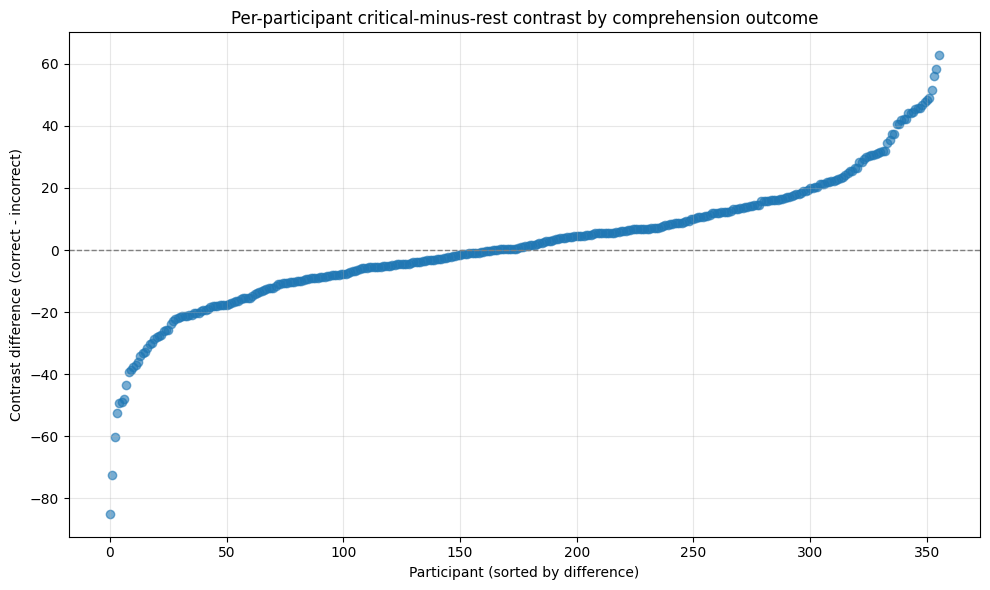

In [27]:
import matplotlib.pyplot as plt

cr = regions.dropna(subset=["critical_pupil", "rest_pupil"]).copy()
cr["crit_minus_rest"] = cr["critical_pupil"] - cr["rest_pupil"]

per_part = (cr.groupby(["participant_id", "is_correct"])["crit_minus_rest"]
            .mean().unstack("is_correct"))
per_part.columns = ["incorrect_contrast", "correct_contrast"]
per_part["difference"] = per_part["correct_contrast"] - per_part["incorrect_contrast"]
per_part = per_part.dropna(subset=["difference"])

n_expected = (per_part["difference"] > 0).sum()
print("Participants with both correct and incorrect trials:", len(per_part))
print(f"Larger contrast on correct trials: {n_expected} of {len(per_part)}")
print("Mean per-participant difference (correct - incorrect):",
      round(per_part["difference"].mean(), 3))

per_part_sorted = per_part.sort_values("difference").reset_index()
plt.figure(figsize=(10, 6))
plt.scatter(range(len(per_part_sorted)), per_part_sorted["difference"], alpha=0.6)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Participant (sorted by difference)")
plt.ylabel("Contrast difference (correct - incorrect)")
plt.title("Per-participant critical-minus-rest contrast by comprehension outcome")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("per_participant_contrast_diff.png", dpi=150)
plt.show()

# **Stage 3: Reading With and Without the Question**

Half of the OneStop readers saw the question before reading each paragraph, and half saw it only afterwards. Here we test whether the critical-span effect depends on knowing in advance which words matter.

## **Section 1: The Two Reader Groups**

We check that each participant belongs to one group only and look at the group sizes. We also save a participant-to-group table, so the next sections don't need to read the raw file again.

In [28]:
import pandas as pd

RAW_PATH = "/content/drive/MyDrive/eyebench_data/OneStop/precomputed_reading_measures/ia_Paragraph.csv"
PREVIEW_OUT = "/content/drive/MyDrive/eyebench_data/preview_groups.csv"

# Read only the columns we need and keep one row per unique combination,
# so this stays light even though the raw file is large.
cols = ["participant_id", "question_preview", "repeated_reading_trial"]
pieces = []
for chunk in pd.read_csv(RAW_PATH, usecols=cols, chunksize=500000, low_memory=False):
    pieces.append(chunk.drop_duplicates())
flags = pd.concat(pieces).drop_duplicates()

# The preview condition should be fixed per participant, since each reader was
# assigned to one group for the whole experiment.
n_values = flags.groupby("participant_id")["question_preview"].nunique()
print("Participants with mixed preview values (expect 0):", (n_values > 1).sum())
print()

# One row per participant with their group.
groups = flags.drop_duplicates("participant_id")[["participant_id", "question_preview"]]
print("Participants per group:")
print(groups["question_preview"].value_counts())
print()

# How the repeated-reading trials are spread across the two groups.
print("Repeated reading by group (rows = preview, columns = repeated reading):")
print(pd.crosstab(flags["question_preview"], flags["repeated_reading_trial"]))

# Save the participant-to-group table for the next sections.
groups.to_csv(PREVIEW_OUT, index=False)
print("\nSaved participant groups to Drive.")

Participants with mixed preview values (expect 0): 0

Participants per group:
question_preview
True     180
False    180
Name: count, dtype: int64

Repeated reading by group (rows = preview, columns = repeated reading):
repeated_reading_trial  False  True 
question_preview                    
False                     180    180
True                      180    180

Saved participant groups to Drive.


## **Section 2: Critical-Span Contrast by Group**

We compare the critical-minus-rest contrast between the two groups, using first readings only, since a reader who already answered a question about a paragraph is no longer reading it blind. Each reader is averaged into a single value, so we compare people rather than trials.

In [29]:
import os
import pandas as pd
import numpy as np
from scipy import stats

RAW_PATH = "/content/drive/MyDrive/eyebench_data/OneStop/precomputed_reading_measures/ia_Paragraph.csv"
PREVIEW_OUT = "/content/drive/MyDrive/eyebench_data/preview_groups.csv"
TRIAL_FLAGS_OUT = "/content/drive/MyDrive/eyebench_data/trial_flags.csv"
TRIAL_KEYS = ["participant_id", "article_id", "paragraph_id", "onestopqa_question_id"]

# Repeated readings are left out by default: a reader who already answered a
# question about the paragraph no longer reads it without knowing what matters.
# Set to False to include them.
FIRST_READING_ONLY = True

# The repeated-reading flag is per trial. We read it from the raw file once and
# save it to Drive, so later runs can skip this slow step.
if os.path.exists(TRIAL_FLAGS_OUT):
    trial_flags = pd.read_csv(TRIAL_FLAGS_OUT)
else:
    cols = TRIAL_KEYS + ["repeated_reading_trial"]
    pieces = []
    for chunk in pd.read_csv(RAW_PATH, usecols=cols, chunksize=500000, low_memory=False):
        pieces.append(chunk.drop_duplicates())
    trial_flags = pd.concat(pieces).drop_duplicates()
    trial_flags.to_csv(TRIAL_FLAGS_OUT, index=False)

# Each trial should have a single value for the flag.
n_values = trial_flags.groupby(TRIAL_KEYS)["repeated_reading_trial"].nunique()
print("Trials with mixed repeated-reading values (expect 0):", (n_values > 1).sum())
trial_flags = trial_flags.drop_duplicates(subset=TRIAL_KEYS)
print("Trials by reading type:")
print(trial_flags["repeated_reading_trial"].value_counts())
print()

# Attach the reading type and the reader's group to the per-trial region table
# from the Stage 2 prep cell.
groups = pd.read_csv(PREVIEW_OUT)
df = regions.merge(trial_flags, on=TRIAL_KEYS).merge(groups, on="participant_id")
if FIRST_READING_ONLY:
    df = df[df["repeated_reading_trial"] == False]
df["group"] = np.where(df["question_preview"], "Saw question first", "Question after")
print("Trials used per group:")
print(df["group"].value_counts())
print()

# Average detrended pupil in each region, per group.
print("Average detrended pupil by region and group:")
print(df.groupby("group")[["critical_pupil", "distractor_pupil", "rest_pupil"]].mean().round(3))
print()

# Critical-minus-rest contrast per trial, then averaged per participant, so each
# reader counts once and trials from the same reader are not treated as independent.
cr = df.dropna(subset=["critical_pupil", "rest_pupil"]).copy()
cr["crit_minus_rest"] = cr["critical_pupil"] - cr["rest_pupil"]
per_part = cr.groupby(["participant_id", "group"])["crit_minus_rest"].mean().reset_index()

# Within each group: is the contrast above zero?
for g, sub in per_part.groupby("group"):
    t, p = stats.ttest_1samp(sub["crit_minus_rest"], 0)
    n_pos = (sub["crit_minus_rest"] > 0).sum()
    print(f"{g}: mean contrast = {sub['crit_minus_rest'].mean():.3f}, "
          f"readers above zero = {n_pos} of {len(sub)}, t = {t:.2f}, p = {p:.2e}")
print()

# Between groups: is the contrast larger for readers who saw the question first?
preview = per_part[per_part["group"] == "Saw question first"]["crit_minus_rest"]
no_preview = per_part[per_part["group"] == "Question after"]["crit_minus_rest"]
t, p = stats.ttest_ind(preview, no_preview, equal_var=False)
pooled_std = np.sqrt((preview.var() + no_preview.var()) / 2)
d = (preview.mean() - no_preview.mean()) / pooled_std
print("Saw question first vs question after (per-participant contrast):")
print(f"  t = {t:.3f}, p = {p:.4f}, Cohen's d = {d:.3f}")

Trials with mixed repeated-reading values (expect 0): 0
Trials by reading type:
repeated_reading_trial
False    20158
True      3888
Name: count, dtype: int64

Trials used per group:
group
Saw question first    9720
Question after        9718
Name: count, dtype: int64

Average detrended pupil by region and group:
                    critical_pupil  distractor_pupil  rest_pupil
group                                                           
Question after               0.936             0.262       0.203
Saw question first           7.028            -2.719      -2.079

Question after: mean contrast = 0.676, readers above zero = 101 of 180, t = 1.00, p = 3.21e-01
Saw question first: mean contrast = 9.001, readers above zero = 152 of 180, t = 11.69, p = 7.80e-24

Saw question first vs question after (per-participant contrast):
  t = 8.113, p = 0.0000, Cohen's d = 0.855


## **Section 2b: Contrast Per Reader, by Group**

Each group is sorted separately and drawn as its own curve, with readers placed by their rank within the group. Where each curve crosses zero shows how many readers in that group have the effect.

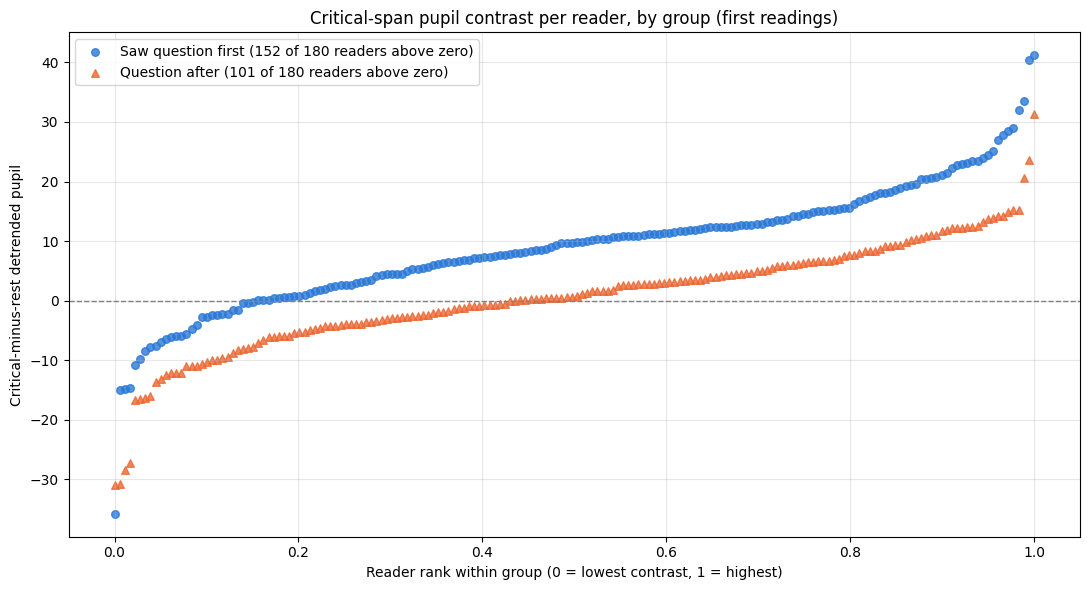

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Reuses per_part from the previous cell: one critical-minus-rest contrast per reader.
# Each group is sorted on its own, and each reader's x position is their rank within
# their group, from 0 (lowest contrast) to 1 (highest). This way the two groups form
# two curves that can be compared directly, instead of overlapping on one curve.
styles = {"Saw question first": ("#2a78d6", "o"),
          "Question after": ("#eb6834", "^")}

plt.figure(figsize=(11, 6))
for g, (color, marker) in styles.items():
    sub = per_part[per_part["group"] == g].sort_values("crit_minus_rest")
    x = np.arange(len(sub)) / (len(sub) - 1)
    n_pos = (sub["crit_minus_rest"] > 0).sum()
    plt.scatter(x, sub["crit_minus_rest"], c=color, marker=marker, s=30, alpha=0.8,
                label=f"{g} ({n_pos} of {len(sub)} readers above zero)")

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Reader rank within group (0 = lowest contrast, 1 = highest)")
plt.ylabel("Critical-minus-rest detrended pupil")
plt.title("Critical-span pupil contrast per reader, by group (first readings)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("per_participant_contrast_by_group.png", dpi=150)
plt.show()

## **Section 3: Can Pupil Locate the Critical Span?**

Within each trial we rank the fixated words by detrended pupil and check where the critical words land, compared with a random set of words of the same size. We run this separately for each group and then compare the groups.

In [31]:
import numpy as np
import pandas as pd
from scipy import stats

rng = np.random.default_rng(0)
N_SHUFFLE = 200

# Fixated words with detrended pupil (from the Stage 2 prep cell), with the reading
# type and the reader's group attached. We use the same first-readings setting as
# Section 2.
data = fix[TRIAL_KEYS + ["pupil_detrended", "in_critical"]].dropna(subset=["pupil_detrended"])
data = data.merge(trial_flags, on=TRIAL_KEYS).merge(groups, on="participant_id")
if FIRST_READING_ONLY:
    data = data[data["repeated_reading_trial"] == False].copy()
data["group"] = np.where(data["question_preview"], "Saw question first", "Question after")

# The ranking test: within each trial we rank the fixated words by detrended pupil,
# take the mean percentile of the critical words, and compare it with a shuffle of
# the critical labels (same count). If pupil says nothing about relevance, the real
# and shuffled percentiles should come out about the same.
rows = []
for keys, g in data.groupby(TRIAL_KEYS + ["group"]):
    n = len(g)
    crit_mask = g["in_critical"].values
    k = crit_mask.sum()
    # Need at least one critical and one non-critical fixated word to rank.
    if k == 0 or k == n:
        continue
    percentile = g["pupil_detrended"].rank(pct=True).values
    real = percentile[crit_mask].mean()
    shuffled = np.mean([percentile[rng.choice(n, size=k, replace=False)].mean()
                        for _ in range(N_SHUFFLE)])
    rows.append({"participant_id": keys[0], "group": keys[-1],
                 "real": real, "shuffled": shuffled})

scores = pd.DataFrame(rows)
scores["diff"] = scores["real"] - scores["shuffled"]

# Results per group, at the trial level.
for g, sub in scores.groupby("group"):
    t, p = stats.ttest_1samp(sub["diff"], 0)
    print(f"{g}: trials = {len(sub)}")
    print(f"  critical percentile real = {sub['real'].mean():.4f}, "
          f"shuffled = {sub['shuffled'].mean():.4f}")
    print(f"  difference = {sub['diff'].mean():.4f}, t = {t:.2f}, p = {p:.2e}")
    print(f"  share of trials beating the shuffle = {(sub['diff'] > 0).mean():.3f}")
print()

# Between groups, one value per reader (their mean real-minus-shuffled difference),
# so trials from the same reader are not treated as independent.
per_reader = scores.groupby(["participant_id", "group"])["diff"].mean().reset_index()
for g, sub in per_reader.groupby("group"):
    print(f"{g}: readers above chance = {(sub['diff'] > 0).sum()} of {len(sub)}")
preview = per_reader[per_reader["group"] == "Saw question first"]["diff"]
no_preview = per_reader[per_reader["group"] == "Question after"]["diff"]
t, p = stats.ttest_ind(preview, no_preview, equal_var=False)
pooled_std = np.sqrt((preview.var() + no_preview.var()) / 2)
d = (preview.mean() - no_preview.mean()) / pooled_std
print("Saw question first vs question after (per-reader difference):")
print(f"  t = {t:.3f}, p = {p:.4f}, Cohen's d = {d:.3f}")

Question after: trials = 9715
  critical percentile real = 0.5115, shuffled = 0.5079
  difference = 0.0036, t = 2.41, p = 1.60e-02
  share of trials beating the shuffle = 0.510
Saw question first: trials = 9692
  critical percentile real = 0.5391, shuffled = 0.5094
  difference = 0.0297, t = 20.74, p = 1.72e-93
  share of trials beating the shuffle = 0.586

Question after: readers above chance = 97 of 180
Saw question first: readers above chance = 150 of 180
Saw question first vs question after (per-reader difference):
  t = 8.914, p = 0.0000, Cohen's d = 0.940


## **Section 4: Contrast and Comprehension Within Each Group**

In Stage 2 the link between the contrast and answering correctly was weak, but that test mixed both groups. Here we repeat it within each group, by trial and by reader.

In [32]:
import numpy as np
from scipy import stats

# Reuses cr from Section 2: first-reading trials with the critical-minus-rest
# contrast, the comprehension label and the reader's group.
for g, sub in cr.groupby("group"):
    print(f"{g}:")

    # Trial level, comparable to the pooled test in Stage 2.
    correct = sub[sub["is_correct"] == True]["crit_minus_rest"]
    incorrect = sub[sub["is_correct"] == False]["crit_minus_rest"]
    t, p = stats.ttest_ind(correct, incorrect, equal_var=False)
    pooled_std = np.sqrt((correct.var() + incorrect.var()) / 2)
    d = (correct.mean() - incorrect.mean()) / pooled_std
    print(f"  trial level: correct = {correct.mean():.3f} (n={len(correct)}), "
          f"incorrect = {incorrect.mean():.3f} (n={len(incorrect)})")
    print(f"               t = {t:.2f}, p = {p:.4f}, Cohen's d = {d:.3f}")

    # Per reader: mean contrast on correct trials minus on incorrect trials.
    # Readers without both kinds of trials cannot give a difference and drop out.
    by_reader = (sub.groupby(["participant_id", "is_correct"])["crit_minus_rest"]
                 .mean().unstack("is_correct"))
    diff = (by_reader[True] - by_reader[False]).dropna()
    t2, p2 = stats.ttest_1samp(diff, 0)
    print(f"  per reader:  larger contrast when correct for {(diff > 0).sum()} of {len(diff)} readers, "
          f"mean difference = {diff.mean():.3f}, t = {t2:.2f}, p = {p2:.4f}")
    print()

Question after:
  trial level: correct = 0.813 (n=7835), incorrect = 0.105 (n=1820)
               t = 0.49, p = 0.6223, Cohen's d = 0.013
  per reader:  larger contrast when correct for 101 of 180 readers, mean difference = 1.374, t = 0.95, p = 0.3426

Saw question first:
  trial level: correct = 9.388 (n=8372), incorrect = 6.380 (n=1255)
               t = 1.80, p = 0.0726, Cohen's d = 0.055
  per reader:  larger contrast when correct for 100 of 176 readers, mean difference = 3.732, t = 2.22, p = 0.0275



## **Section 5: Robustness Check - Detrending Within Each Group**

Until now, one position curve was used for all readers. Here each group gets its own curve, and we check that the difference between the groups still holds.

In [33]:
import numpy as np
import pandas as pd
from scipy import stats

# Start from the fixated words (Stage 2 prep cell), which already have pupil
# centered within each reader and a position bin, and keep the same trials as
# Section 2.
chk = fix.merge(trial_flags, on=TRIAL_KEYS).merge(groups, on="participant_id")
if FIRST_READING_ONLY:
    chk = chk[chk["repeated_reading_trial"] == False].copy()

# How different are the two groups' position curves in the first place?
curves = (chk.groupby(["position_bin", "question_preview"], observed=True)["pupil_centered"]
          .mean().unstack("question_preview"))
print("Largest gap between the two groups' position curves:",
      round((curves[True] - curves[False]).abs().max(), 3))
print()

# Detrend again, this time with a separate position curve for each group: the
# expected pupil is the mean centered pupil of the same group at the same position.
expected = chk.groupby(["question_preview", "position_bin"], observed=True)["pupil_centered"].transform("mean")
chk["pupil_detrended_grp"] = chk["pupil_centered"] - expected

# Same contrast as Section 2, built from the new detrended values.
crit_mean = (chk[chk["region"] == "critical"]
             .groupby(TRIAL_KEYS)["pupil_detrended_grp"].mean().rename("critical_pupil"))
rest_mean = (chk[chk["region"] == "rest"]
             .groupby(TRIAL_KEYS)["pupil_detrended_grp"].mean().rename("rest_pupil"))
cr_grp = pd.concat([crit_mean, rest_mean], axis=1).dropna().reset_index()
cr_grp = cr_grp.merge(groups, on="participant_id")
cr_grp["group"] = np.where(cr_grp["question_preview"], "Saw question first", "Question after")
cr_grp["crit_minus_rest"] = cr_grp["critical_pupil"] - cr_grp["rest_pupil"]

# One value per reader, then the same tests as Section 2.
per_part_grp = cr_grp.groupby(["participant_id", "group"])["crit_minus_rest"].mean().reset_index()
for g, sub in per_part_grp.groupby("group"):
    t, p = stats.ttest_1samp(sub["crit_minus_rest"], 0)
    n_pos = (sub["crit_minus_rest"] > 0).sum()
    print(f"{g}: mean contrast = {sub['crit_minus_rest'].mean():.3f}, "
          f"readers above zero = {n_pos} of {len(sub)}, t = {t:.2f}, p = {p:.2e}")
print()

preview = per_part_grp[per_part_grp["group"] == "Saw question first"]["crit_minus_rest"]
no_preview = per_part_grp[per_part_grp["group"] == "Question after"]["crit_minus_rest"]
t, p = stats.ttest_ind(preview, no_preview, equal_var=False)
pooled_std = np.sqrt((preview.var() + no_preview.var()) / 2)
d = (preview.mean() - no_preview.mean()) / pooled_std
print("Saw question first vs question after, with within-group detrending:")
print(f"  t = {t:.3f}, p = {p:.4f}, Cohen's d = {d:.3f}")

Largest gap between the two groups' position curves: 16.987

Question after: mean contrast = 1.541, readers above zero = 110 of 180, t = 2.27, p = 2.47e-02
Saw question first: mean contrast = 7.946, readers above zero = 145 of 180, t = 10.23, p = 1.23e-19

Saw question first vs question after, with within-group detrending:
  t = 6.203, p = 0.0000, Cohen's d = 0.654
